In [47]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim

In [48]:
train = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv")
test = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv")

In [49]:

X = train.iloc[:,:-1].values
y = train.iloc[:,-1].values

X_test = test.iloc[:,:-1].values
y_test = test.iloc[:,-1].values

# Correct unpacking order: Features first, then targets
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_tensor = torch.tensor(X_train,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train,dtype = torch.float32)

X_val_tensor = torch.tensor(X_val,dtype = torch.float32)
y_val_tensor = torch.tensor(y_val,dtype = torch.float32)

X_test_tensor = torch.tensor(X_test,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test,dtype = torch.float32)

X_train_tensor = X_train_tensor.unsqueeze(2)
X_val_tensor = X_val_tensor.unsqueeze(2)
X_test_tensor = X_test_tensor.unsqueeze(2)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

train_load = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Val và Test chỉ để đánh giá, không cần shuffle
val_load = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_load = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim

class ECG_CNN_LSTM(nn.Module):
    def __init__(self,num_classes = 5):
        super(ECG_CNN_LSTM,self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels = 1 , out_channels = 32 , kernel_size =5 ,stride = 1, padding =2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2,stride =2),

            nn.Conv1d(in_channels = 32, out_channels =64 , kernel_size = 5 ,stride = 1 ,padding =2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size = 2 ,stride = 2)
        )
        self.lstm = nn.LSTM(input_size =64 , hidden_size =64 , num_layers =2 , batch_first = True , dropout = 0.2)
        self.fc = nn.Linear(64,num_classes)

    def forward(self,x):
        x = x.permute(0,2,1)
        x = self.cnn(x)
        x = x.permute(0,2,1)
        lstm_out , (hidden ,cell) = self.lstm(x)
        hidden_last = hidden[-1,:,:]
        out = self.fc(hidden_last)
        return out
        

In [51]:
# 1. Khởi tạo mô hình
model = ECG_CNN_LSTM(num_classes=5)

# 2. Khai báo thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3. Đẩy MÔ HÌNH lên GPU (Sửa torch.to thành model.to)
model = model.to(device)

# 4. Bọc MÔ HÌNH bằng DataParallel (Sửa device = ... thành model = nn.DataParallel...)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

# 5. Khai báo Loss và Optimizer
# Tính trọng số gắt hơn (Không dùng np.sqrt nữa)
criterion = nn.CrossEntropyLoss()

# (Lưu ý nhỏ: Đổi tên biến 'optim' thành 'optimizer' để không bị trùng 
# với tên module 'torch.optim' sinh ra lỗi báo biến bị đè)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [52]:
EPOCHS = 15
best_val_loss = float('inf')

print("Bắt đầu huấn luyện...")

for epoch in range(EPOCHS):
    # ==========================================
    # 1. PHA HUẤN LUYỆN (TRAINING)
    # ==========================================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0 

    for batch_X, batch_y in train_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        # Thống kê Train
        train_loss += loss.item()
        _, predict = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        
        # [SỬA Ở ĐÂY]: Bổ sung dòng cộng dồn số câu đúng
        train_correct += (predict == batch_y).sum().item()
        
    # [SỬA Ở ĐÂY]: Kéo hai dòng này ra ngoài vòng lặp batch (lùi ra 1 tab)
    avg_train_loss = train_loss / len(train_load)
    train_acc = 100 * train_correct / train_total
    
    # ==========================================
    # 2. PHA XÁC THỰC (VALIDATION)
    # ==========================================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_X, batch_y in val_load:
            batch_X = batch_X.to(device)
            batch_y = batch_y.long().to(device)
            
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Thống kê Val
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
    avg_val_loss = val_loss / len(val_load)
    val_acc = 100 * val_correct / val_total
    
    # ==========================================
    # 3. IN KẾT QUẢ & LƯU MÔ HÌNH TỐT NHẤT
    # ==========================================
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"| Train Loss: {avg_train_loss:.4f} (Acc: {train_acc:.2f}%) "
          f"| Val Loss: {avg_val_loss:.4f} (Acc: {val_acc:.2f}%)")
    
    # Lưu Model Checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        
        # Mẹo nâng cao: Nếu dùng DataParallel, cần lưu .module.state_dict() 
        # để sau này load lại vào 1 GPU hoặc CPU không bị lỗi tiền tố "module."
        if isinstance(model, nn.DataParallel):
            torch.save(model.module.state_dict(), 'best_ecg_cnn_lstm.pth')
        else:
            torch.save(model.state_dict(), 'best_ecg_cnn_lstm.pth')
            
        print("  -> Đã lưu phiên bản mô hình xuất sắc nhất!")

print("\nHoàn tất quá trình huấn luyện!")

Bắt đầu huấn luyện...
Epoch [1/15] | Train Loss: 0.3941 (Acc: 89.68%) | Val Loss: 0.2377 (Acc: 94.25%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [2/15] | Train Loss: 0.1995 (Acc: 94.70%) | Val Loss: 0.1671 (Acc: 95.09%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [3/15] | Train Loss: 0.1521 (Acc: 95.84%) | Val Loss: 0.1308 (Acc: 96.59%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [4/15] | Train Loss: 0.1248 (Acc: 96.59%) | Val Loss: 0.1132 (Acc: 96.85%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [5/15] | Train Loss: 0.1096 (Acc: 96.98%) | Val Loss: 0.1029 (Acc: 97.20%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [6/15] | Train Loss: 0.0976 (Acc: 97.36%) | Val Loss: 0.1110 (Acc: 96.94%)
Epoch [7/15] | Train Loss: 0.0928 (Acc: 97.42%) | Val Loss: 0.0832 (Acc: 97.60%)
  -> Đã lưu phiên bản mô hình xuất sắc nhất!
Epoch [8/15] | Train Loss: 0.0840 (Acc: 97.65%) | Val Loss: 0.0930 (Acc: 97.47%)
Epoch [9/15] | Train Loss: 0.0797 (Acc: 97.77%) | Val Loss: 

In [57]:
model.eval()

total_test_loss = 0
correct_test = 0
total_test = 0

print("Bắt đầu đánh giá trên tập Test...")

# Tắt lưu trữ đạo hàm
with torch.no_grad():
    for batch_X, batch_y in test_load:
        # Đẩy cả dữ liệu và nhãn lên GPU
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        # Lan truyền xuôi
        outputs = model(batch_X)
        
        # 1. Tính toán Test Loss (Tùy chọn, để xem model có bị overfit không)
        loss = criterion(outputs, batch_y)
        total_test_loss += loss.item()
        
        # 2. Tính Accuracy
        # Lấy nhãn có xác suất cao nhất
        _, predicted = torch.max(outputs, 1)
        
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

# Tổng hợp kết quả
avg_test_loss = total_test_loss / len(test_load)
test_accuracy = 100 * correct_test / total_test

print(f"--- KẾT QUẢ TẬP TEST ---")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Bắt đầu đánh giá trên tập Test...
--- KẾT QUẢ TẬP TEST ---
Test Loss: 0.0667
Test Accuracy: 98.14%


In [58]:

from sklearn.metrics import classification_report

print("Bắt đầu tải trọng số tốt nhất và đánh giá trên tập Test...")

# 1. BẮT BUỘC: Tải lại bộ trọng số tốt nhất đã lưu từ pha Validation
# Nếu không có bước này, bạn chỉ đang test trên Epoch cuối cùng (có thể đã bị overfit)
model.load_state_dict(torch.load('best_ecg_lstm.pth'))

# 2. Chuyển sang chế độ đánh giá (tắt Dropout)
model.eval()

total_test_loss = 0
all_preds = []
all_targets = []

# 3. Quét qua tập Test
with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        total_test_loss += loss.item()
        
        # Lấy nhãn dự đoán
        _, predicted = torch.max(outputs, 1)
        
        # Đưa dữ liệu từ GPU về CPU và lưu vào mảng
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(batch_y.cpu().numpy())

# Chuyển đổi list thành mảng numpy
y_pred_np = np.array(all_preds)
y_true_np = np.array(all_targets)

# 4. In kết quả tổng quan
avg_test_loss = total_test_loss / len(test_load)
print(f"\n--- KẾT QUẢ TỔNG QUAN ---")
print(f"Test Loss: {avg_test_loss:.4f}")

# 5. In báo cáo chi tiết (Precision, Recall, F1-Score)
print("\n--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---")
# Tham số digits=4 giúp in ra 4 chữ số thập phân cho chuẩn xác
report = classification_report(y_true_np, y_pred_np, digits=4, zero_division=0)
print(report)

Bắt đầu tải trọng số tốt nhất và đánh giá trên tập Test...

--- KẾT QUẢ TỔNG QUAN ---
Test Loss: 0.0667

--- BÁO CÁO PHÂN LOẠI CHI TIẾT ---
              precision    recall  f1-score   support

           0     0.9833    0.9970    0.9901     72470
           1     0.9509    0.6451    0.7687      2223
           2     0.9731    0.9426    0.9576      5788
           3     0.8200    0.7535    0.7854       641
           4     0.9888    0.9790    0.9839      6431

    accuracy                         0.9814     87553
   macro avg     0.9432    0.8634    0.8971     87553
weighted avg     0.9810    0.9814    0.9804     87553



Đang quét tập Test để thu thập xác suất dự đoán...


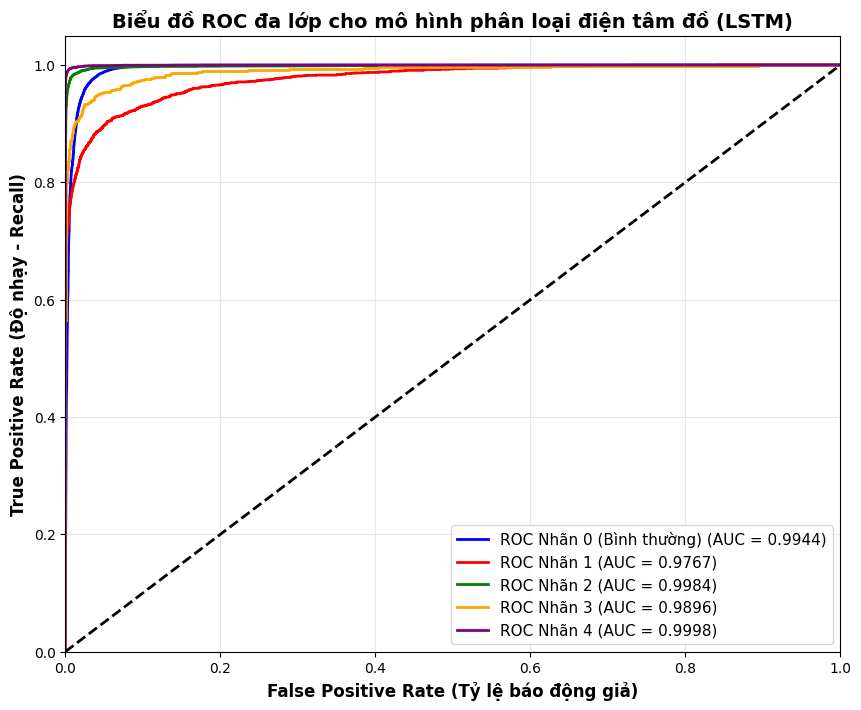

In [59]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Đang quét tập Test để thu thập xác suất dự đoán...")

model.eval()

all_targets = []
all_probs = [] # Mảng mới để lưu xác suất thay vì nhãn

with torch.no_grad():
    for batch_X, batch_y in test_load:
        batch_X = batch_X.to(device)
        batch_y = batch_y.long().to(device)
        
        outputs = model(batch_X)
        
        # SỬ DỤNG SOFTMAX ĐỂ LẤY XÁC SUẤT (Từ 0.0 đến 1.0)
        probs = F.softmax(outputs, dim=1)
        
        all_targets.extend(batch_y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

y_true_np = np.array(all_targets)
y_probs_np = np.array(all_probs)

# 1. Chuyển đổi nhãn thật sang định dạng One-Hot (ví dụ: Nhãn 2 -> [0, 0, 1, 0, 0])
n_classes = 5
y_true_bin = label_binarize(y_true_np, classes=[0, 1, 2, 3, 4])

# 2. Khởi tạo biểu đồ Matplotlib
plt.figure(figsize=(10, 8))

# Cài đặt màu và tên cho 5 nhãn
colors = ['blue', 'red', 'green', 'orange', 'purple']
class_names = ['Nhãn 0 (Bình thường)', 'Nhãn 1', 'Nhãn 2', 'Nhãn 3', 'Nhãn 4']

# 3. Dùng vòng lặp để tính và vẽ đường ROC cho từng nhãn
for i in range(n_classes):
    # Tính FPR (Trục X) và TPR (Trục Y)
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_np[:, i])
    
    # Tính diện tích AUC
    roc_auc = auc(fpr, tpr)
    
    # Vẽ đường cong
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc:.4f})')

# 4. Vẽ đường chéo đứt nét (Baseline - Ngưỡng của một mô hình đoán mò, AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# 5. Căn chỉnh thẩm mỹ cho biểu đồ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo động giả)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Độ nhạy - Recall)', fontsize=12, fontweight='bold')
plt.title('Biểu đồ ROC đa lớp cho mô hình phân loại điện tâm đồ (LSTM)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Xuất ảnh
plt.show()

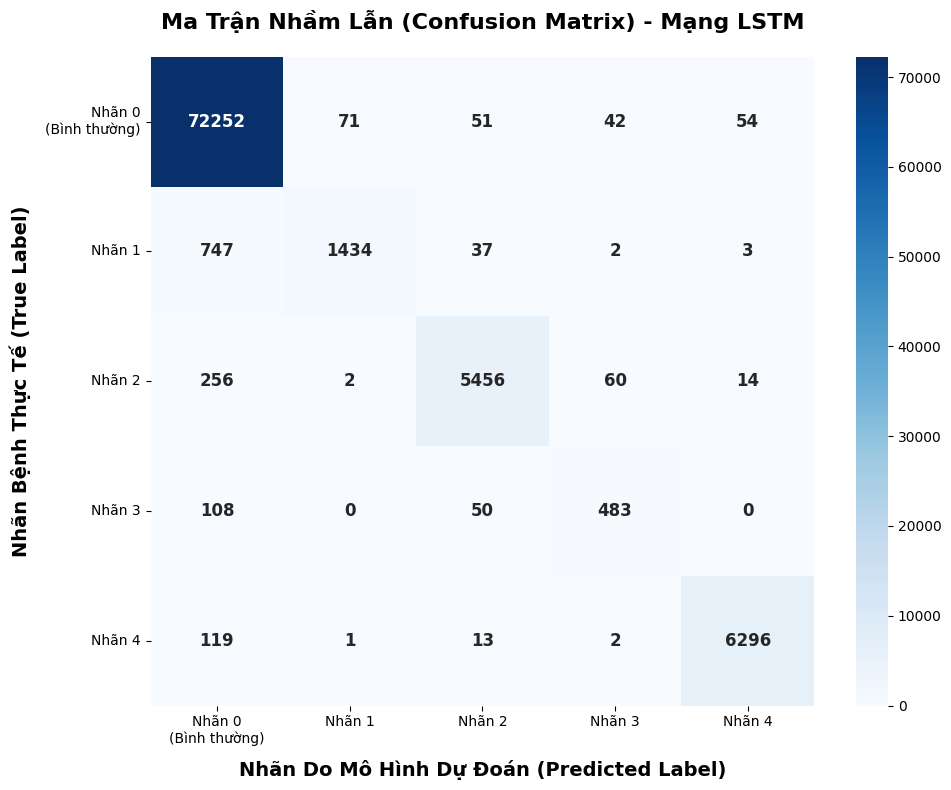

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Chuyển đổi mảng xác suất (từ bước vẽ ROC) thành nhãn dự đoán
# Lấy vị trí (index) có xác suất cao nhất làm kết quả dự đoán
y_pred_np = np.argmax(y_probs_np, axis=1)

# 2. Tính toán Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_true_np, y_pred_np)

# 3. Khởi tạo khung biểu đồ
plt.figure(figsize=(10, 8))
class_names = ['Nhãn 0\n(Bình thường)', 'Nhãn 1', 'Nhãn 2', 'Nhãn 3', 'Nhãn 4']

# 4. Vẽ Heatmap bằng Seaborn
# Tham số cmap='Blues' tạo dải màu xanh chuyên nghiệp (đậm = nhiều, nhạt = ít)
# Tham số fmt='d' ép kiểu hiển thị là số nguyên (không có số thập phân)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12, "weight": "bold"})

# 5. Căn chỉnh thẩm mỹ cho dễ nhìn
plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Mạng LSTM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nhãn Do Mô Hình Dự Đoán (Predicted Label)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Nhãn Bệnh Thực Tế (True Label)', fontsize=14, fontweight='bold', labelpad=10)

# Xoay chữ ở trục X để không bị đè lên nhau
plt.xticks(rotation=0) 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()